# Model Evaluation

## Objective

In this notebook we will evaluate the trained Logistic Regression model using different evaluation metrics.

Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report
- ROC Curve

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv").squeeze()

In [3]:
with open("../models/best_model.pkl", "rb") as file:
    model = pickle.load(file)

In [4]:
predictions = model.predict(X_test)

In [5]:
probabilities = model.predict_proba(X_test)[:,1]

In [6]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

Accuracy : 0.8038379530916845


## Accuracy

Accuracy tells us what percentage of predictions are correct.

In [7]:
precision = precision_score(y_test, predictions)

print("Precision :", precision)

Precision : 0.649390243902439


## Precision

Precision answers:

Out of all customers predicted as churn, how many actually churned?

In [8]:
recall = recall_score(y_test, predictions)

print("Recall :", recall)

Recall : 0.56951871657754


## Recall

Recall answers:

Out of all actual churn customers, how many did the model identify?

In [9]:
f1 = f1_score(y_test, predictions)

print("F1 Score :", f1)

F1 Score : 0.6068376068376068


## F1 Score

F1 Score is the harmonic mean of Precision and Recall.

In [10]:
auc = roc_auc_score(y_test, probabilities)

print("ROC-AUC :", auc)

ROC-AUC : 0.8359989335873398


## ROC-AUC

ROC-AUC measures how well the model separates churn and non-churn customers.

In [12]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [13]:
cm = confusion_matrix(y_test, predictions)

cm

array([[918, 115],
       [161, 213]])

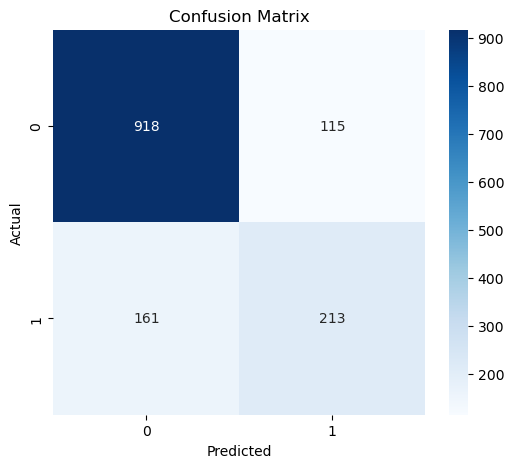

In [14]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Confusion Matrix Interpretation

- True Positive: Correctly predicted churn customers.
- True Negative: Correctly predicted non-churn customers.
- False Positive: Customer predicted to churn but actually stayed.
- False Negative: Customer predicted to stay but actually churned.

False Negatives are more costly because the company loses customers without taking preventive action.

In [15]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities
)

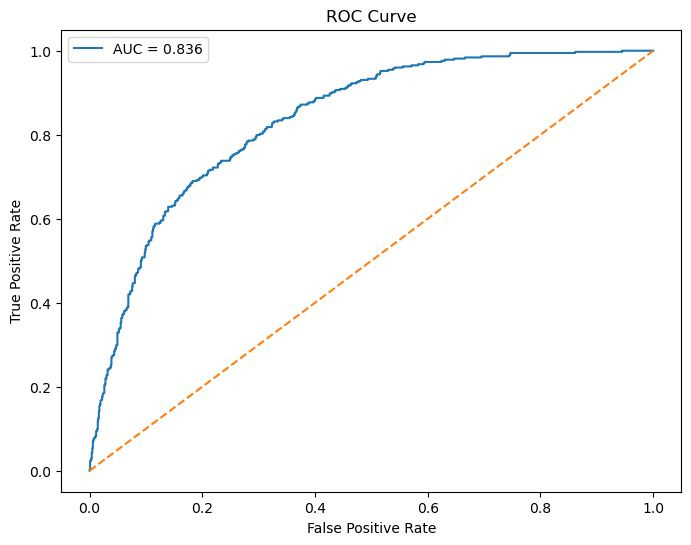

In [16]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## ROC Curve

A curve closer to the top-left corner indicates better model performance.

Higher AUC means better separation between churn and non-churn customers.

In [17]:
metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

})

metrics

,Metric,Value
0,Accuracy,0.803838
1,Precision,0.649390
2,Recall,0.569519
3,F1 Score,0.606838
4,ROC-AUC,0.835999


In [18]:
metrics.to_csv("../data/model_metrics.csv", index=False)

print("Metrics Saved Successfully!")

Metrics Saved Successfully!


# Final Observation

The Logistic Regression model performs well in identifying customer churn.

Business teams should prioritize improving Recall because missing churn customers leads to direct revenue loss.

This model can now be interpreted using Explainable AI techniques (SHAP).